In [1]:
import pandas as pd
import numpy as np

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("PS4.csv")

df.head()

,created_utc,score,domain,id,title,author,ups,downs,num_comments,permalink,...,over_18,thumbnail,subreddit_id,edited,link_flair_css_class,author_flair_css_class,is_self,name,url,distinguished
0,1.372267e+09,1025,i.imgur.com,1h4be5,PS4 Box Contents,anexanhume,1260,235,382,http://www.reddit.com/r/PS4/comments/1h4be5/ps...,...,False,http://d.thumbs.redditmedia.com/IJtV-r1PVSwp_q...,t5_2rrlp,False,NaN,ps,False,t3_1h4be5,http://i.imgur.com/W6DjEor.jpg,NaN
1,1.373648e+09,982,farm4.staticflickr.com,1i5vyc,If Sony wants to put a dent in the used game m...,jasonlarge,1358,376,181,http://www.reddit.com/r/PS4/comments/1i5vyc/if...,...,False,http://e.thumbs.redditmedia.com/JqMC224QVZjlIe...,t5_2rrlp,False,NaN,NaN,False,t3_1i5vyc,http://farm4.staticflickr.com/3675/9268443285_...,NaN
2,1.374835e+09,670,i.imgur.com,1j38l7,Launch PS3 &amp; PS4 side-by-side Size Comparison,tamearmeisce,796,126,102,http://www.reddit.com/r/PS4/comments/1j38l7/la...,...,False,http://d.thumbs.redditmedia.com/M304tI2DuWp3GQ...,t5_2rrlp,False,NaN,NaN,False,t3_1j38l7,http://i.imgur.com/enwPeC9.png,NaN
3,1.372155e+09,666,i.imgur.com,1h12wu,Didn't realize just how big the PS4 controller...,sneakysaf,927,261,140,http://www.reddit.com/r/PS4/comments/1h12wu/di...,...,False,http://b.thumbs.redditmedia.com/iBzV_hslg3lw9x...,t5_2rrlp,False,NaN,NaN,False,t3_1h12wu,http://i.imgur.com/uP4KpSg.jpg,NaN
4,1.371053e+09,658,gamestop.de,1g7aru,PS4 console box art,Parablank,760,102,134,http://www.reddit.com/r/PS4/comments/1g7aru/ps...,...,False,http://a.thumbs.redditmedia.com/FSRQK423Li5CxO...,t5_2rrlp,False,NaN,empty-sce,False,t3_1g7aru,http://www.gamestop.de/productImages/251054/3m...,NaN


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   created_utc             1000 non-null   float64
 1   score                   1000 non-null   int64  
 2   domain                  1000 non-null   str    
 3   id                      1000 non-null   str    
 4   title                   1000 non-null   str    
 5   author                  969 non-null    str    
 6   ups                     1000 non-null   int64  
 7   downs                   1000 non-null   int64  
 8   num_comments            1000 non-null   int64  
 9   permalink               1000 non-null   str    
 10  selftext                203 non-null    str    
 11  link_flair_text         20 non-null     str    
 12  over_18                 1000 non-null   bool   
 13  thumbnail               1000 non-null   str    
 14  subreddit_id            1000 non-null   str    
 15 

In [4]:
df["text"] = df["title"]

In [5]:
stop_words = set(stopwords.words("english"))

def clean_text(text):
    
    tokens = word_tokenize(str(text).lower())
    
    words = [word for word in tokens if word.isalpha()]
    
    filtered = [w for w in words if w not in stop_words]
    
    return " ".join(filtered)

df["clean_text"] = df["text"].apply(clean_text)

df.head()

,created_utc,score,domain,id,title,author,ups,downs,num_comments,permalink,...,subreddit_id,edited,link_flair_css_class,author_flair_css_class,is_self,name,url,distinguished,text,clean_text
0,1.372267e+09,1025,i.imgur.com,1h4be5,PS4 Box Contents,anexanhume,1260,235,382,http://www.reddit.com/r/PS4/comments/1h4be5/ps...,...,t5_2rrlp,False,NaN,ps,False,t3_1h4be5,http://i.imgur.com/W6DjEor.jpg,NaN,PS4 Box Contents,box contents
1,1.373648e+09,982,farm4.staticflickr.com,1i5vyc,If Sony wants to put a dent in the used game m...,jasonlarge,1358,376,181,http://www.reddit.com/r/PS4/comments/1i5vyc/if...,...,t5_2rrlp,False,NaN,NaN,False,t3_1i5vyc,http://farm4.staticflickr.com/3675/9268443285_...,NaN,If Sony wants to put a dent in the used game m...,sony wants put dent used game market
2,1.374835e+09,670,i.imgur.com,1j38l7,Launch PS3 &amp; PS4 side-by-side Size Comparison,tamearmeisce,796,126,102,http://www.reddit.com/r/PS4/comments/1j38l7/la...,...,t5_2rrlp,False,NaN,NaN,False,t3_1j38l7,http://i.imgur.com/enwPeC9.png,NaN,Launch PS3 &amp; PS4 side-by-side Size Comparison,launch amp size comparison
3,1.372155e+09,666,i.imgur.com,1h12wu,Didn't realize just how big the PS4 controller...,sneakysaf,927,261,140,http://www.reddit.com/r/PS4/comments/1h12wu/di...,...,t5_2rrlp,False,NaN,NaN,False,t3_1h12wu,http://i.imgur.com/uP4KpSg.jpg,NaN,Didn't realize just how big the PS4 controller...,realize big controller saw
4,1.371053e+09,658,gamestop.de,1g7aru,PS4 console box art,Parablank,760,102,134,http://www.reddit.com/r/PS4/comments/1g7aru/ps...,...,t5_2rrlp,False,NaN,empty-sce,False,t3_1g7aru,http://www.gamestop.de/productImages/251054/3m...,NaN,PS4 console box art,console box art


In [6]:
vectorizer = TfidfVectorizer(max_features=1000)

X = vectorizer.fit_transform(df["clean_text"])

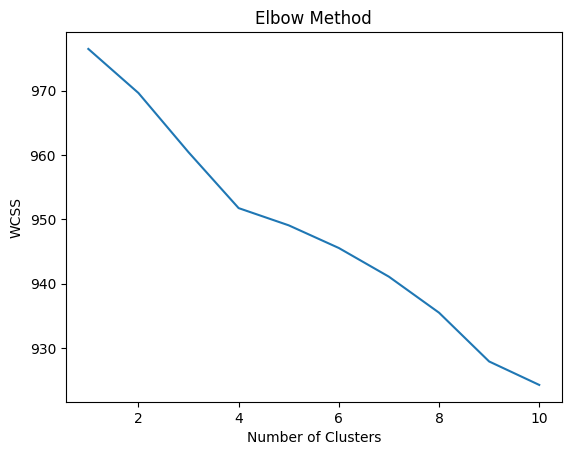

In [7]:
wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)
    
plt.plot(range(1,11), wcss)
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [8]:
kmeans = KMeans(n_clusters=4, random_state=42)

df["cluster"] = kmeans.fit_predict(X)

df.head()

,created_utc,score,domain,id,title,author,ups,downs,num_comments,permalink,...,edited,link_flair_css_class,author_flair_css_class,is_self,name,url,distinguished,text,clean_text,cluster
0,1.372267e+09,1025,i.imgur.com,1h4be5,PS4 Box Contents,anexanhume,1260,235,382,http://www.reddit.com/r/PS4/comments/1h4be5/ps...,...,False,NaN,ps,False,t3_1h4be5,http://i.imgur.com/W6DjEor.jpg,NaN,PS4 Box Contents,box contents,1
1,1.373648e+09,982,farm4.staticflickr.com,1i5vyc,If Sony wants to put a dent in the used game m...,jasonlarge,1358,376,181,http://www.reddit.com/r/PS4/comments/1i5vyc/if...,...,False,NaN,NaN,False,t3_1i5vyc,http://farm4.staticflickr.com/3675/9268443285_...,NaN,If Sony wants to put a dent in the used game m...,sony wants put dent used game market,2
2,1.374835e+09,670,i.imgur.com,1j38l7,Launch PS3 &amp; PS4 side-by-side Size Comparison,tamearmeisce,796,126,102,http://www.reddit.com/r/PS4/comments/1j38l7/la...,...,False,NaN,NaN,False,t3_1j38l7,http://i.imgur.com/enwPeC9.png,NaN,Launch PS3 &amp; PS4 side-by-side Size Comparison,launch amp size comparison,1
3,1.372155e+09,666,i.imgur.com,1h12wu,Didn't realize just how big the PS4 controller...,sneakysaf,927,261,140,http://www.reddit.com/r/PS4/comments/1h12wu/di...,...,False,NaN,NaN,False,t3_1h12wu,http://i.imgur.com/uP4KpSg.jpg,NaN,Didn't realize just how big the PS4 controller...,realize big controller saw,1
4,1.371053e+09,658,gamestop.de,1g7aru,PS4 console box art,Parablank,760,102,134,http://www.reddit.com/r/PS4/comments/1g7aru/ps...,...,False,NaN,empty-sce,False,t3_1g7aru,http://www.gamestop.de/productImages/251054/3m...,NaN,PS4 console box art,console box art,1


In [9]:
for i in range(4):
    print("\nCluster", i)
    print(df[df["cluster"] == i]["title"].head(10))


Cluster 0
12     PS4′s digital library lets you play your games...
16     PS+ won't be required to record and stream vid...
29      EA Raises Prices Of Next-Gen Games To £54.99/$84
40     Here's a high-res picture of what PS4 boxart f...
46            Sony Will Announce New PS4 Games In August
103    IGN: Sony will show 40 games at E3 (across PS4...
120    We Hate To See All PS4 Games Being FPS - Sony'...
136    24 first party PS4 games &amp; 8 new IPs left ...
157    9 PS4 games you get for FREE (aswell as links ...
181    PS4 is like 'a really perfect gaming PC,' says...
Name: title, dtype: str

Cluster 1
0                                      PS4 Box Contents
2     Launch PS3 &amp; PS4 side-by-side Size Comparison
3     Didn't realize just how big the PS4 controller...
4                                   PS4 console box art
6     Official PlayStation Used Game Instructional V...
8                              PS4 Becomes #1 on Amazon
9     Yes you can swap out the PS4 hard drive fo

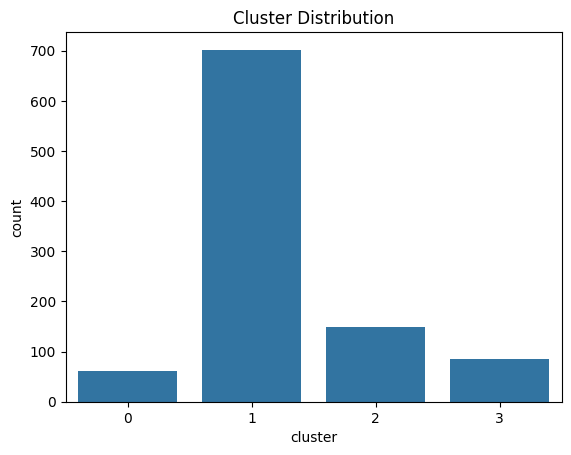

In [10]:
sns.countplot(x="cluster", data=df)

plt.title("Cluster Distribution")
plt.show()


In [11]:
df.to_csv("PS4_clustered.csv", index=False)